1. Библиотеки и GPU

In [1]:
import json, time, uuid, shutil, os
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from scipy.optimize import least_squares, nnls
import pynvml as nv

torch.cuda.set_device(0)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.allow_tf32 = False
torch.backends.cuda.matmul.allow_tf32 = False
torch.manual_seed(2026)
os.chdir('/kaggle/working')
out = Path('/kaggle/working') / datetime.now().strftime('hw1_%Y%m%d_%H%M%S_%f')
(out / 'figures').mkdir(parents=True)
print(torch.cuda.get_device_name(0))


Tesla T4


2. Сеть

In [2]:
model = nn.Sequential(
    nn.Conv2d(3, 32, 7, stride=2, padding=3, bias=False), nn.ReLU(inplace=True),
    nn.MaxPool2d(3, stride=2, padding=1),
    nn.Conv2d(32, 64, 5, padding=2, bias=False), nn.ReLU(inplace=True),
    nn.Conv2d(64, 128, 3, stride=2, padding=1, bias=False), nn.ReLU(inplace=True),
    nn.Conv2d(128, 256, 1, bias=False), nn.ReLU(inplace=True),
    nn.Conv2d(256, 256, 3, stride=2, padding=1, bias=False), nn.ReLU(inplace=True),
    nn.Conv2d(256, 512, 1, bias=False), nn.ReLU(inplace=True),
    nn.AdaptiveAvgPool2d(1), nn.Flatten(1),
    nn.Linear(512, 256), nn.ReLU(inplace=True), nn.Linear(256, 100)
).cuda().eval()

print(sum(p.numel() for p in model.parameters()))


1040324


3. Формулы

In [3]:
# MAC = 2; сравнение ReLU/MaxPool = 1. Включены GAP и bias Linear.
def flops(image_size, batch):
    s, b = np.asarray(image_size), np.asarray(batch)
    return b * (17751.0 * s**2 + 313956)


# Память тензоров без workspace cuDNN.
def memory(image_size, batch):
    s, b = np.asarray(image_size), np.asarray(batch)
    return 4161296.0 + 52.0 * b * s**2


def latency(image_size, batch, theta):
    s, b = np.asarray(image_size), np.asarray(batch)
    q = 4.0 * (1040324 + b * (91.0 * s**2 + 2148))
    return theta['launch_s'] + np.maximum(
        theta['seconds_per_flop'] * flops(s, b), theta['seconds_per_byte'] * q)


def energy(image_size, batch, theta_energy):
    s, b = np.asarray(image_size), np.asarray(batch)
    q = 4.0 * (1040324 + b * (91.0 * s**2 + 2148))
    return (theta_energy['base_power_w'] * latency(s, b, theta_energy['latency'])
            + theta_energy['joules_per_flop'] * flops(s, b)
            + theta_energy['joules_per_byte'] * q)


4. Размеры входа и измерение мощности

In [4]:
base_s = [32, 64, 128, 224, 256, 384, 512]
base_b = [1, 2, 4, 8, 16, 32, 64, 128, 256]
rng = np.random.default_rng(2026)
extra_s = rng.choice(sorted(set(range(32, 513, 16)) - set(base_s)), 4, replace=False).tolist()
extra_b = rng.choice(sorted(set(range(1, 257)) - set(base_b)), 3, replace=False).tolist()
grid = [(s,b) for s in base_s + extra_s for b in base_b + extra_b]
rng.shuffle(grid)

nv.nvmlInit()
u = torch.cuda.get_device_properties(0).uuid
if isinstance(u, bytes):
    u = str(uuid.UUID(bytes=u)) if len(u) == 16 else u.decode()
u = str(u).lower().removeprefix('gpu-')
handle = None
for i in range(nv.nvmlDeviceGetCount()):
    h = nv.nvmlDeviceGetHandleByIndex(i)
    v = nv.nvmlDeviceGetUUID(h)
    v = v.decode() if isinstance(v, bytes) else str(v)
    if v.lower().removeprefix('gpu-') == u:
        handle = h
assert handle is not None, 'Не совпали UUID CUDA и NVML'
print('Мощность GPU:', nv.nvmlDeviceGetPowerUsage(handle) / 1000, 'W')
meta = dict(gpu=torch.cuda.get_device_name(0), torch=torch.__version__, cuda=torch.version.cuda,
            cudnn=torch.backends.cudnn.version(), extra_s=extra_s, extra_b=extra_b, seed=2026,
            precision='FP32', benchmark=False, tf32=False, warmup=10, repeats=30,
            energy_method='NVML power integral over 3 seconds / number of passes')
(out / 'metadata.json').write_text(json.dumps(meta, indent=2))


Мощность GPU: 27.944 W


371

5. Замеры: 132 конфигурации. Энергия - интеграл мощности всей GPU за 3 секунды, делённый на число проходов.

In [5]:
assert not (out / 'measurements.csv').exists(), 'Для повторного замера выполни ячейку 1'
rows = []
with torch.inference_mode():
    for s, b in grid:
        x = y = None
        torch.cuda.empty_cache()
        free, _ = torch.cuda.mem_get_info()
        row = dict(S=s, B=b, status='OK', is_validation=int(s in extra_s or b in extra_b),
                   memory_budget_bytes=free + torch.cuda.memory_allocated())
        try:
            x = torch.randn(b, 3, s, s, device='cuda')
            for _ in range(10):
                model(x)
            torch.cuda.synchronize()
            torch.cuda.reset_peak_memory_stats()
            y = model(x)
            torch.cuda.synchronize()
            row['memory_bytes'] = torch.cuda.max_memory_allocated()
            y = None
            times = []
            for _ in range(30):
                start = time.perf_counter()
                y = model(x)
                torch.cuda.synchronize()
                times.append(time.perf_counter() - start)
                y = None
            row['latency_s'] = np.median(times)

            power = nv.nvmlDeviceGetPowerUsage(handle) / 1000
            start = time.perf_counter()
            samples, n = [(start, power)], 0
            while True:
                model(x)
                torch.cuda.synchronize()
                n += 1
                now = time.perf_counter()
                if now - samples[-1][0] >= 0.05 or now - start >= 3:
                    samples.append((now, nv.nvmlDeviceGetPowerUsage(handle) / 1000))
                if now - start >= 3:
                    break
            joules = sum((t1-t0)*(p0+p1)/2 for (t0,p0),(t1,p1) in zip(samples, samples[1:]))
            row['energy_j'] = joules / n
            assert row['energy_j'] > 0, 'NVML вернул нулевую энергию'
        except torch.cuda.OutOfMemoryError:
            row['status'] = 'OOM'
        finally:
            x = y = None
        rows.append(row)
        pd.DataFrame(rows).to_csv(out / 'measurements.csv', index=False)
        print(len(rows), s, b, row['status'])
df = pd.DataFrame(rows)


1 128 128 OK
2 32 167 OK
3 256 1 OK
4 48 98 OK
5 352 8 OK
6 384 95 OK
7 64 128 OK
8 64 64 OK
9 384 256 OK
10 64 32 OK
11 384 167 OK
12 48 167 OK
13 352 4 OK
14 224 256 OK
15 256 167 OK
16 64 1 OK
17 112 64 OK
18 400 16 OK
19 512 16 OK
20 64 16 OK
21 32 98 OK
22 384 128 OK
23 64 4 OK
24 352 16 OK
25 112 128 OK
26 112 95 OK
27 32 32 OK
28 352 2 OK
29 112 32 OK
30 512 64 OK
31 384 4 OK
32 384 1 OK
33 512 95 OK
34 512 256 OK
35 400 4 OK
36 128 2 OK
37 224 16 OK
38 224 95 OK
39 112 98 OK
40 48 8 OK
41 128 98 OK
42 112 1 OK
43 48 95 OK
44 128 32 OK
45 112 4 OK
46 256 128 OK
47 512 32 OK
48 352 64 OK
49 48 128 OK
50 512 4 OK
51 256 8 OK
52 400 95 OK
53 224 4 OK
54 352 128 OK
55 112 16 OK
56 32 256 OK
57 32 8 OK
58 48 2 OK
59 512 167 OK
60 512 98 OK
61 48 32 OK
62 112 2 OK
63 400 1 OK
64 128 95 OK
65 224 32 OK
66 400 64 OK
67 224 167 OK
68 64 8 OK
69 32 4 OK
70 384 8 OK
71 512 2 OK
72 352 1 OK
73 64 167 OK
74 512 1 OK
75 352 256 OK
76 224 128 OK
77 256 16 OK
78 400 98 OK
79 400 256 OK
80 384 9

6. Подбор коэффициентов на основных размерах. Дополнительные размеры оставляем для сравнения.

In [6]:
ok = df[df.status == 'OK'].copy()
s, b = ok.S.to_numpy(), ok.B.to_numpy()
fit_rows = ok.is_validation.to_numpy() == 0
f = flops(s, b) / 1e9
q = 4 * (1040324 + b * (91.0 * s**2 + 2148)) / 1e9
t = ok.latency_s.to_numpy()
f0, q0, t0 = f[fit_rows], q[fit_rows], t[fit_rows]
fits = [least_squares(lambda p: (p[0] + np.maximum(p[1]*f0, p[2]*q0) - t0) / t0,
                     [t0.min()/10, np.median(t0/f0)*r, np.median(t0/q0)/r],
                     bounds=(0, np.inf), x_scale='jac', max_nfev=5000) for r in [0.1, 1, 10]]
p = min((r for r in fits if r.success), key=lambda r: np.sum(r.fun**2)).x
theta = dict(launch_s=float(p[0]), seconds_per_flop=float(p[1]/1e9), seconds_per_byte=float(p[2]/1e9))
e = ok.energy_j.to_numpy()
A = np.column_stack([latency(s,b,theta), f, q])[fit_rows] / e[fit_rows,None]
scale = np.linalg.norm(A, axis=0)
c = nnls(A/scale, np.ones(fit_rows.sum()))[0] / scale
theta_energy = dict(base_power_w=float(c[0]), joules_per_flop=float(c[1]/1e9),
                    joules_per_byte=float(c[2]/1e9), latency=theta)
(out / 'theta.json').write_text(json.dumps(dict(latency=theta, energy=theta_energy), indent=2))
print(theta, theta_energy)


{'launch_s': 0.0003498141294272861, 'seconds_per_flop': 3.3971934019866126e-13, 'seconds_per_byte': 1.410570221298417e-11} {'base_power_w': 67.4977774238458, 'joules_per_flop': 7.169770830829229e-13, 'joules_per_byte': 0.0, 'latency': {'launch_s': 0.0003498141294272861, 'seconds_per_flop': 3.3971934019866126e-13, 'seconds_per_byte': 1.410570221298417e-11}}


7. Расчёт против измерения. Прямая означает точное совпадение.

latency_s ошибка на дополнительных размерах: 27.67 %
memory_bytes ошибка на дополнительных размерах: 53.18 %
energy_j ошибка на дополнительных размерах: 24.36 %


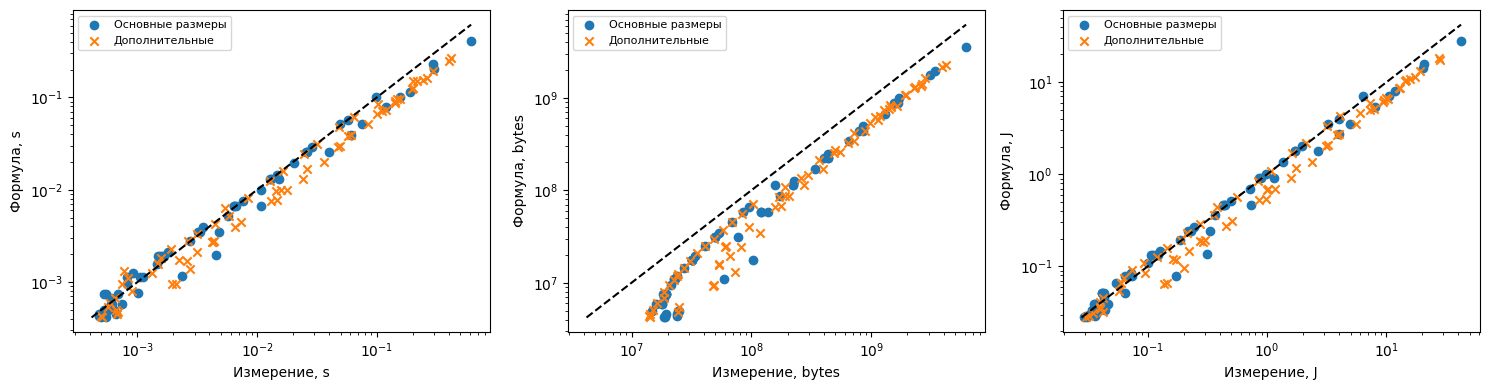

,S,B,status,oom_formula


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, name, unit, calc in zip(axes, ['latency_s','memory_bytes','energy_j'], ['s','bytes','J'],
                              [latency(s,b,theta), memory(s,b), energy(s,b,theta_energy)]):
    actual = ok[name].to_numpy()
    ax.scatter(actual[fit_rows], calc[fit_rows], label='Основные размеры')
    ax.scatter(actual[~fit_rows], calc[~fit_rows], marker='x', label='Дополнительные')
    limits = [min(actual.min(), calc.min()), max(actual.max(), calc.max())]
    ax.plot(limits, limits, 'k--')
    ax.set(xscale='log', yscale='log', xlabel=f'Измерение, {unit}', ylabel=f'Формула, {unit}')
    ax.legend(fontsize=8)
    error = 100*np.mean(np.abs(calc[~fit_rows]/actual[~fit_rows] - 1))
    print(name, 'ошибка на дополнительных размерах:', round(error, 2), '%')
fig.tight_layout()
fig.savefig(out / 'figures' / 'comparison.png', dpi=160)
plt.show()
df['memory_formula'] = memory(df.S, df.B)
df['oom_formula'] = df.memory_formula > df.memory_budget_bytes
df.to_csv(out / 'measurements.csv', index=False)
display(df[df.status.eq('OOM') | df.oom_formula][['S','B','status','oom_formula']])


8. FLOPs, B = 1. Profiler считает MAC Conv/Linear; дополнительные операции показаны отдельно.

/usr/local/lib/python3.12/dist-packages/torch/profiler/profiler.py:217: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


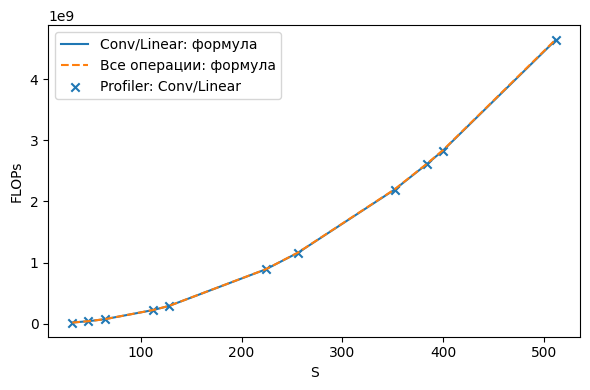

In [8]:
counts = []
with torch.inference_mode():
    for size in sorted(base_s + extra_s):
        x = torch.randn(1, 3, size, size, device='cuda')
        with torch.profiler.profile(with_flops=True) as prof:
            model(x)
        counts.append([size, sum(e.flops for e in prof.key_averages())])
        del x
counts = np.array(counts)
plt.figure(figsize=(6, 4))
plt.plot(counts[:,0], 17712 * counts[:,0]**2 + 313344, label='Conv/Linear: формула')
plt.plot(counts[:,0], flops(counts[:,0], 1), '--', label='Все операции: формула')
plt.scatter(counts[:,0], counts[:,1], marker='x', label='Profiler: Conv/Linear')
plt.xlabel('S'); plt.ylabel('FLOPs'); plt.legend(); plt.tight_layout()
plt.savefig(out / 'figures' / 'flops.png', dpi=160)
plt.show()
pd.DataFrame(counts, columns=['S','flops_profiled']).to_csv(out / 'flops.csv', index=False)


9. Скачать результаты

In [9]:
from IPython.display import FileLink
archive = shutil.make_archive(str(out), 'zip', root_dir=out)
display(FileLink(Path(archive).name))


/kaggle/working/hw1_20260926_205427_535077.zip